# ABLA — Controlled Ablation of ESN Input Magnitude

This notebook isolates the effect of the ESN input-weight magnitude on multi-temperature
effusivity prediction and reservoir dynamics:

\[
s_{in}\in\{0.00,0.05,0.10,0.25,0.50,1.00,1.50,1.64,2.00,3.00,5.00\}.
\]

For a fixed base input matrix \(\mathbf{W}_{in,0}\), each condition uses

\[
\mathbf{W}_{in}=s_{in}\mathbf{W}_{in,0}.
\]

At zero, the measured channels cannot drive the reservoir, although the bias and recurrent
dynamics remain. Increasing the magnitude strengthens the contribution of `P` and `dP/dt`
inside `tanh`. Deliberately large values are retained to reveal nonlinear amplification and
possible saturation.

Everything else is fixed: 20 reservoir units, leak rate 0.30, spectral radius 0.90,
no washout, absolute smoothed `P + dP/dt`, a 0–3 s window, nine summaries per unit,
27 thermal features, fixed XGBoost settings, three reservoir seeds, and identical
14-fold LOMO splits. Every condition supplies the same 207 predictors.


# 1. Imports and fixed configuration


In [1]:
from pathlib import Path
import json
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import linalg
from scipy.signal import savgol_filter
from sklearn.compose import TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor


In [2]:
TEMPERATURE_FOLDERS = ("30C", "40C", "50C", "60C")
TARGET = "eff"
ANALYSIS_WINDOW = (0.0, 3.0)

# Includes no measured-input drive, weak/moderate drive, the optimized 4Av5 neighborhood,
# and deliberately strong values that may push tanh toward saturation.
INPUT_MAGNITUDE_VALUES = (
    0.00, 0.05, 0.10, 0.25, 0.50, 1.00, 1.50, 1.64, 2.00, 3.00, 5.00,
)

FIXED_ESN_PARAMS = {
    "res_size": 20,
    "leak_rate": 0.30,
    "spectral_radius": 0.90,
    "washout": 0,
}
XGB_PARAMS = {
    "n_estimators": 300, "max_depth": 3, "learning_rate": 0.05,
    "subsample": 0.80, "colsample_bytree": 0.80,
    "min_child_weight": 5, "reg_alpha": 0.10, "reg_lambda": 10.0,
}

RESERVOIR_SEEDS = (42, 43, 44)
RANDOM_STATE = 42
CLIP_PREDICTIONS_TO_TRAIN_RANGE = True
SUMMARY_NAMES = (
    "mean", "std", "min", "max", "initial",
    "net_change", "slope", "mean_abs", "abs_auc",
)

cwd = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in (cwd, cwd.parent) if (p / "data").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the project root or notebooks directory.")
DATA_ROOT = PROJECT_ROOT / "data" / "02_preprocessed"
RESULTS_DIR = PROJECT_ROOT / "results" / "ablation"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULT_STEM = "ABLA_input_magnitude_primary_dprimary_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO"

print("Input magnitudes:", INPUT_MAGNITUDE_VALUES)
print("Fixed ESN HPs:", FIXED_ESN_PARAMS)
print("Fixed XGBoost HPs:", XGB_PARAMS)
print("Reservoir seeds:", RESERVOIR_SEEDS)


Input magnitudes: (0.0, 0.05, 0.1, 0.25, 0.5, 1.0, 1.5, 1.64, 2.0, 3.0, 5.0)
Fixed ESN HPs: {'res_size': 20, 'leak_rate': 0.3, 'spectral_radius': 0.9, 'washout': 0}
Fixed XGBoost HPs: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 5, 'reg_alpha': 0.1, 'reg_lambda': 10.0}
Reservoir seeds: (42, 43, 44)


## Controlled-ablation interpretation

This is not an Optuna or Bayesian search. Every declared input magnitude is evaluated
explicitly while reservoir size, leak rate, spectral radius, seed, input data, feature
representation, regressor, and LOMO folds remain fixed. The pooled metrics identify an
exploratory best value, while per-material results test whether the effect generalizes across
unseen materials. Including 1.64 diagnoses the neighborhood of the current optimized 4Av5 value;
it does not make 1.64 a preselected winner.


# 2. Load trials and assign standard material properties


In [3]:
STANDARD_PROPERTIES = {
    "ps_foam": {"k": .034, "rho": 25., "cp": 1400.},
    "pu_foam": {"k": .043, "rho": 30., "cp": 1400.},
    "cork": {"k": .043, "rho": 240., "cp": 1800.},
    "wood": {"k": .150, "rho": 700., "cp": 1700.},
    "pdms": {"k": .150, "rho": 970., "cp": 1460.},
    "gypsum": {"k": .170, "rho": 800., "cp": 1090.},
    "cement": {"k": .290, "rho": 1440., "cp": 750.},
    "graphite": {"k": 100., "rho": 1820., "cp": 710.},
    "bismuth": {"k": 8.1, "rho": 9780., "cp": 130.},
    "titanium": {"k": 21.9, "rho": 4506., "cp": 523.},
    "nickel": {"k": 90.9, "rho": 8908., "cp": 461.},
    "iron": {"k": 80.4, "rho": 7874., "cp": 449.},
    "aluminum": {"k": 237., "rho": 2700., "cp": 897.},
    "copper": {"k": 401., "rho": 8960., "cp": 385.},
}
ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood", "pdms": "pdms", "gypsum": "gypsum", "cement": "cement",
    "graphite": "graphite", "carbon": "graphite", "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium", "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron", "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []
for temperature in TEMPERATURE_FOLDERS:
    for path in sorted((DATA_ROOT / temperature).glob("*.csv")):
        frame = pd.read_csv(path)
        if required - set(frame.columns):
            continue
        frame["Temperature"] = temperature
        frame["Temperature_C"] = float(temperature.rstrip("C"))
        frames.append(frame)
if not frames:
    raise ValueError("No valid preprocessed trial files were found.")

DATA = pd.concat(frames, ignore_index=True).replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary", "Temperature_C"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required) + ["Temperature", "Temperature_C"]).copy()
DATA["Trial"] = DATA["Trial"].astype(int)
normalized = DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
DATA["Sample"] = normalized.map(ALIASES)
if DATA["Sample"].isna().any():
    raise KeyError("At least one material name does not have a recognized alias.")
for name in ("k", "rho", "cp"):
    DATA[name] = DATA["Sample"].map(lambda material: STANDARD_PROPERTIES[material][name])
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA["trial_id"] = (
    DATA["Temperature"] + "__" + DATA["Sample"] + "_trial_" + DATA["Trial"].astype(str)
)
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)
print("Raw trial count:", DATA["trial_id"].nunique())


Raw trial count: 336


# 3. Contact alignment and fixed 0–3 s window


In [4]:
def find_contact_time(trial, smooth_window=15, polyorder=2, threshold_frac=.30, skip_samples=5):
    clean = (
        trial[["Time", "Primary"]].dropna().sort_values("Time")
        .drop_duplicates("Time").reset_index(drop=True)
    )
    time_values = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time_values) <= 0):
        raise ValueError("Invalid sequence for contact detection.")
    time_values, signal = time_values[skip_samples:], signal[skip_samples:]
    window = min(smooth_window, len(signal))
    if window % 2 == 0:
        window -= 1
    smooth = savgol_filter(signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, time_values)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(time_values[elbow])


aligned_trials = {}
metadata_rows = []
for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue
    trial["time_from_contact"] = trial["Time"] - contact
    trial = trial[trial["time_from_contact"].between(*ANALYSIS_WINDOW)].copy()
    if len(trial) < 8:
        warnings.warn(f"Skipping {trial_id}: too few samples in 0–3 s.")
        continue
    trial = trial.reset_index(drop=True)
    aligned_trials[trial_id] = trial
    metadata_rows.append({
        "trial_id": trial_id,
        "Temperature": trial["Temperature"].iloc[0],
        "Temperature_C": float(trial["Temperature_C"].iloc[0]),
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })

METADATA = pd.DataFrame(metadata_rows).sort_values("trial_id").reset_index(drop=True)
if METADATA["Sample"].nunique() != 14:
    warnings.warn(f"Expected 14 materials but retained {METADATA['Sample'].nunique()}.")
print("Aligned trials retained:", len(METADATA))
print("Materials retained:", METADATA["Sample"].nunique())


Aligned trials retained: 336
Materials retained: 14


# 4. Absolute-smoothed `P + dP/dt` inputs and variable-input-magnitude reservoir


In [5]:
def smooth_signal(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= 5 else values.copy()
    )


def esn_input(trial):
    """Direct absolute smoothed primary and dPrimary/dt; no fitted scaling."""
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    return np.column_stack([primary, np.gradient(primary, time_values)])


class ManualReservoir:
    def __init__(self, input_magnitude, random_state):
        self.res_size = int(FIXED_ESN_PARAMS["res_size"])
        self.leak_rate = float(FIXED_ESN_PARAMS["leak_rate"])
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(FIXED_ESN_PARAMS["spectral_radius"])
        self.washout = int(FIXED_ESN_PARAMS["washout"])
        rng = np.random.default_rng(random_state)
        # Identical random base matrix for a given seed; only its magnitude changes.
        self.Win = (rng.random((self.res_size, 1 + 2)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid unscaled recurrent-matrix spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 2:
            raise ValueError("Expected P and dP/dt inputs.")
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            proposed = np.tanh(
                self.Win @ np.r_[1.0, row].reshape(-1, 1) + self.W @ x
            )
            x = (1 - self.leak_rate) * x + self.leak_rate * proposed
            states.append(x[:, 0].copy())
        states = np.asarray(states)
        if len(states) <= self.washout:
            raise ValueError("The reservoir sequence is shorter than the washout.")
        return states[self.washout:]


def summarize_states(time_values, states):
    time_values = np.asarray(time_values, float)
    states = np.asarray(states, float)
    output = {}
    for unit in range(states.shape[1]):
        x = states[:, unit]
        prefix = f"esn_u{unit:03d}"
        output.update({
            f"{prefix}_mean": float(np.mean(x)),
            f"{prefix}_std": float(np.std(x)),
            f"{prefix}_min": float(np.min(x)),
            f"{prefix}_max": float(np.max(x)),
            f"{prefix}_initial": float(x[0]),
            f"{prefix}_net_change": float(x[-1] - x[0]),
            f"{prefix}_slope": float(np.polyfit(time_values, x, 1)[0]),
            f"{prefix}_mean_abs": float(np.mean(np.abs(x))),
            f"{prefix}_abs_auc": float(np.trapezoid(np.abs(x), time_values)),
        })
    return output


# 5. Scalar thermal features over the same 0–3 s interval


In [6]:
THERMAL_SLOPE_WINDOWS = {
    "early": (0.0, 1.0),
    "middle": (1.0, 2.0),
    "late": (2.0, 3.0),
}


def signal_slope(time_values, values, window):
    mask = (time_values >= window[0]) & (time_values <= window[1])
    if mask.sum() < 3:
        return np.nan
    return float(np.polyfit(time_values[mask], values[mask], 1)[0])


def extract_thermal_features(trial):
    time_values = trial["time_from_contact"].to_numpy(float)
    primary = smooth_signal(trial["Primary"])
    secondary = smooth_signal(trial["Secondary"])
    difference = primary - secondary
    result = {}
    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time_values)
        result[f"thermal_{name}_final_change"] = float(change[-1])
        result[f"thermal_{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"thermal_{name}_response_auc"] = float(np.trapezoid(np.abs(change), time_values))
        result[f"thermal_{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"thermal_{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time_values))
        for window_name, window in THERMAL_SLOPE_WINDOWS.items():
            result[f"thermal_{name}_{window_name}_slope"] = signal_slope(
                time_values, signal, window
            )

    primary_auc = result["thermal_primary_response_auc"]
    result["thermal_secondary_primary_auc_ratio"] = (
        result["thermal_secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["thermal_initial_sensor_difference"] = float(difference[0])
    result["thermal_final_sensor_difference"] = float(difference[-1])
    return result


THERMAL_FEATURES = pd.DataFrame([
    {"trial_id": trial_id, **extract_thermal_features(trial)}
    for trial_id, trial in aligned_trials.items()
]).set_index("trial_id").sort_index()
print("Scalar thermal predictors:", THERMAL_FEATURES.shape[1])
display(THERMAL_FEATURES.head())


Scalar thermal predictors: 27


,thermal_primary_final_change,thermal_primary_max_abs_change,thermal_primary_response_auc,thermal_primary_max_abs_rate,thermal_primary_rate_auc,thermal_primary_early_slope,thermal_primary_middle_slope,thermal_primary_late_slope,thermal_secondary_final_change,thermal_secondary_max_abs_change,...,thermal_difference_max_abs_change,thermal_difference_response_auc,thermal_difference_max_abs_rate,thermal_difference_rate_auc,thermal_difference_early_slope,thermal_difference_middle_slope,thermal_difference_late_slope,thermal_secondary_primary_auc_ratio,thermal_initial_sensor_difference,thermal_final_sensor_difference
trial_id,,,,,,,,,,,,,,,,,,,,,
30C__aluminum_trial_1,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.608193e-07,-2.301865e-07,-7.393007e-07,7.393007e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.999514e-07,1.968456e-07,0.108039,-0.000040,-0.000043
30C__aluminum_trial_2,-0.000003,0.000003,0.000007,0.000004,0.000003,-0.000002,-5.356806e-07,-2.233930e-07,-7.777622e-07,7.777622e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.770283e-07,1.954258e-07,0.126702,-0.000040,-0.000043
30C__aluminum_trial_3,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-4.910211e-07,-2.395687e-07,-8.261538e-07,8.261538e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-2.242352e-07,1.772203e-07,0.137653,-0.000040,-0.000043
30C__aluminum_trial_4,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.429477e-07,-2.277291e-07,-7.784615e-07,7.784615e-07,...,0.000003,0.000006,0.000003,0.000003,-0.000002,-3.218157e-07,1.910936e-07,0.130203,-0.000040,-0.000043
30C__aluminum_trial_5,-0.000003,0.000003,0.000007,0.000003,0.000003,-0.000002,-5.403697e-07,-2.391434e-07,-8.559441e-07,8.559441e-07,...,0.000002,0.000006,0.000003,0.000003,-0.000002,-3.093597e-07,2.082574e-07,0.151386,-0.000041,-0.000043


# 6. Precompute summarized ESN features for every input magnitude and seed


In [7]:
ESN_FEATURES = {}
FEATURE_GENERATION_SECONDS = {}

for input_magnitude in INPUT_MAGNITUDE_VALUES:
    started = time.perf_counter()
    for seed in RESERVOIR_SEEDS:
        print(f"Generating summarized ESN features: IM={input_magnitude:.2f}, seed={seed}")
        reservoir = ManualReservoir(input_magnitude=input_magnitude, random_state=seed)
        rows = []
        for trial_id in METADATA["trial_id"]:
            trial = aligned_trials[trial_id]
            time_values = trial["time_from_contact"].to_numpy(float)
            states = reservoir.run(esn_input(trial))
            state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
            rows.append({"trial_id": trial_id, **summarize_states(state_time, states)})
        esn_table = pd.DataFrame(rows).set_index("trial_id").sort_index()
        ESN_FEATURES[(input_magnitude, seed)] = esn_table.join(
            THERMAL_FEATURES, how="left", validate="one_to_one"
        )
    FEATURE_GENERATION_SECONDS[input_magnitude] = time.perf_counter() - started

fixed_predictors = len(SUMMARY_NAMES) * FIXED_ESN_PARAMS["res_size"] + THERMAL_FEATURES.shape[1]
outer_training_trials = len(METADATA) - int(
    (METADATA["Sample"] == METADATA["Sample"].iloc[0]).sum()
)
FEATURE_COUNTS = pd.DataFrame([
    {
        "input_magnitude": input_magnitude,
        "reservoir_units": FIXED_ESN_PARAMS["res_size"],
        "esn_predictors": len(SUMMARY_NAMES) * FIXED_ESN_PARAMS["res_size"],
        "thermal_predictors": THERMAL_FEATURES.shape[1],
        "total_predictors": fixed_predictors,
        "outer_training_trials": outer_training_trials,
        "predictor_to_training_trial_ratio": fixed_predictors / outer_training_trials,
        "feature_generation_seconds": FEATURE_GENERATION_SECONDS[input_magnitude],
    }
    for input_magnitude in INPUT_MAGNITUDE_VALUES
])
display(FEATURE_COUNTS)


Generating summarized ESN features: IM=0.00, seed=42
Generating summarized ESN features: IM=0.00, seed=43
Generating summarized ESN features: IM=0.00, seed=44
Generating summarized ESN features: IM=0.05, seed=42
Generating summarized ESN features: IM=0.05, seed=43
Generating summarized ESN features: IM=0.05, seed=44
Generating summarized ESN features: IM=0.10, seed=42
Generating summarized ESN features: IM=0.10, seed=43
Generating summarized ESN features: IM=0.10, seed=44
Generating summarized ESN features: IM=0.25, seed=42
Generating summarized ESN features: IM=0.25, seed=43
Generating summarized ESN features: IM=0.25, seed=44
Generating summarized ESN features: IM=0.50, seed=42
Generating summarized ESN features: IM=0.50, seed=43
Generating summarized ESN features: IM=0.50, seed=44
Generating summarized ESN features: IM=1.00, seed=42
Generating summarized ESN features: IM=1.00, seed=43
Generating summarized ESN features: IM=1.00, seed=44
Generating summarized ESN features: IM=1.50, s

,input_magnitude,reservoir_units,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds
0,0.00,20,180,27,207,312,0.663462,4.270553
1,0.05,20,180,27,207,312,0.663462,1.573206
2,0.10,20,180,27,207,312,0.663462,1.208881
3,0.25,20,180,27,207,312,0.663462,1.217136
4,0.50,20,180,27,207,312,0.663462,1.060915
5,1.00,20,180,27,207,312,0.663462,1.016525
6,1.50,20,180,27,207,312,0.663462,1.016529
7,1.64,20,180,27,207,312,0.663462,1.015799
8,2.00,20,180,27,207,312,0.663462,1.006796
9,3.00,20,180,27,207,312,0.663462,1.101840


# 7. Leakage-safe LOMO evaluation at every input magnitude


In [8]:
def make_regressor(seed):
    xgb = XGBRegressor(
        objective="reg:squarederror", random_state=int(seed), n_jobs=-1,
        tree_method="hist", verbosity=0, **XGB_PARAMS,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base, func=np.log1p, inverse_func=np.expm1, check_inverse=False
    )


def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    target_range = float(np.ptp(y_true))
    return {
        "n": len(y_true),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": float(r2_score(y_true, y_pred)) if target_range > 0 else np.nan,
        "median_ape_pct": float(np.median(np.abs((y_true - y_pred) / y_true)) * 100),
    }


logo = LeaveOneGroupOut()
prediction_rows, fold_rows, evaluation_seconds = [], [], {}

for input_magnitude in INPUT_MAGNITUDE_VALUES:
    started = time.perf_counter()
    print(f"\nEvaluating input magnitude {input_magnitude:.2f}")
    for fold, (train_idx, test_idx) in enumerate(
        logo.split(METADATA, groups=METADATA["Sample"]), start=1
    ):
        train_meta = METADATA.iloc[train_idx].reset_index(drop=True)
        test_meta = METADATA.iloc[test_idx].reset_index(drop=True)
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()
        y_train = train_meta[TARGET].to_numpy(float)
        y_test = test_meta[TARGET].to_numpy(float)
        held_out = str(test_meta["Sample"].iloc[0])

        seed_predictions = []
        for seed in RESERVOIR_SEEDS:
            features = ESN_FEATURES[(input_magnitude, seed)]
            X_train = features.loc[train_ids].reset_index(drop=True)
            X_test = features.loc[test_ids].reset_index(drop=True)
            model = make_regressor(seed)
            model.fit(X_train, y_train)
            prediction = model.predict(X_test)
            if CLIP_PREDICTIONS_TO_TRAIN_RANGE:
                prediction = np.clip(prediction, y_train.min(), y_train.max())
            seed_predictions.append(prediction)

        prediction = np.mean(seed_predictions, axis=0)
        residual = prediction - y_test
        rmse = float(np.sqrt(np.mean(residual ** 2)))
        fold_rows.append({
            "input_magnitude": input_magnitude, "fold": fold,
            "held_out_material": held_out, "n": len(y_test),
            "mae": float(np.mean(np.abs(residual))), "rmse": rmse,
            "nrmse_training_range": rmse / float(np.ptp(y_train)),
            "mean_error_bias": float(np.mean(residual)),
            "median_ape_pct": float(np.median(np.abs(residual / y_test)) * 100),
        })
        for row_index, (_, meta_row) in enumerate(test_meta.iterrows()):
            prediction_rows.append({
                "input_magnitude": input_magnitude, "fold": fold,
                "trial_id": meta_row["trial_id"],
                "Temperature": meta_row["Temperature"],
                "Temperature_C": meta_row["Temperature_C"],
                "Sample": meta_row["Sample"], "Trial": meta_row["Trial"],
                "y_true": y_test[row_index], "y_pred": prediction[row_index],
            })
    evaluation_seconds[input_magnitude] = time.perf_counter() - started
    print(f"Completed IM={input_magnitude:.2f} in {evaluation_seconds[input_magnitude]/60:.1f} min")

OOF = pd.DataFrame(prediction_rows)
FOLD_METRICS = pd.DataFrame(fold_rows)
OVERALL = pd.DataFrame([
    {"input_magnitude": float(input_magnitude), **pooled_metrics(part["y_true"], part["y_pred"])}
    for input_magnitude, part in OOF.groupby("input_magnitude", sort=True)
])
OVERALL["fold_nrmse_sd"] = OVERALL["input_magnitude"].map(
    FOLD_METRICS.groupby("input_magnitude")["nrmse_training_range"].std(ddof=1)
)
OVERALL["evaluation_seconds"] = OVERALL["input_magnitude"].map(evaluation_seconds)
OVERALL = OVERALL.merge(FEATURE_COUNTS, on="input_magnitude", how="left", validate="one_to_one")
OVERALL["J_exploratory"] = (
    OVERALL["nrmse_range"] + .10 * (1 - OVERALL["r2"]) + .10 * OVERALL["fold_nrmse_sd"]
)
OVERALL = OVERALL.sort_values("input_magnitude").reset_index(drop=True)
display(OVERALL)

best = OVERALL.loc[OVERALL["J_exploratory"].idxmin()]
print(
    f"Exploratory best input magnitude: IM={best['input_magnitude']:.2f}; "
    f"NRMSE={best['nrmse_range']:.4f}, R²={best['r2']:.4f}, "
    f"J={best['J_exploratory']:.4f}"
)



Evaluating input magnitude 0.00
Completed IM=0.00 in 0.1 min

Evaluating input magnitude 0.05
Completed IM=0.05 in 0.2 min

Evaluating input magnitude 0.10
Completed IM=0.10 in 0.2 min

Evaluating input magnitude 0.25
Completed IM=0.25 in 0.2 min

Evaluating input magnitude 0.50
Completed IM=0.50 in 0.2 min

Evaluating input magnitude 1.00
Completed IM=1.00 in 0.2 min

Evaluating input magnitude 1.50
Completed IM=1.50 in 0.2 min

Evaluating input magnitude 1.64
Completed IM=1.64 in 0.2 min

Evaluating input magnitude 2.00
Completed IM=2.00 in 0.2 min

Evaluating input magnitude 3.00
Completed IM=3.00 in 0.2 min

Evaluating input magnitude 5.00
Completed IM=5.00 in 0.2 min


,input_magnitude,n,mae,rmse,nrmse_range,r2,median_ape_pct,fold_nrmse_sd,evaluation_seconds,reservoir_units,esn_predictors,thermal_predictors,total_predictors,outer_training_trials,predictor_to_training_trial_ratio,feature_generation_seconds,J_exploratory
0,0.00,336,4700.454775,8315.230701,0.223780,0.449602,53.416056,0.260007,8.896752,20,180,27,207,312,0.663462,4.270553,0.304820
1,0.05,336,4572.244000,8269.139237,0.222539,0.455687,54.104832,0.268345,12.857867,20,180,27,207,312,0.663462,1.573206,0.303805
2,0.10,336,4611.290364,8258.578058,0.222255,0.457077,54.757660,0.266874,12.795949,20,180,27,207,312,0.663462,1.208881,0.303235
3,0.25,336,4574.827361,8245.661002,0.221907,0.458774,55.362571,0.267140,11.205271,20,180,27,207,312,0.663462,1.217136,0.302744
4,0.50,336,4615.406280,8267.446491,0.222494,0.455910,57.011328,0.266570,13.986467,20,180,27,207,312,0.663462,1.060915,0.303560
5,1.00,336,4416.271925,7991.006893,0.215054,0.491687,54.422835,0.259083,12.512633,20,180,27,207,312,0.663462,1.016525,0.291794
6,1.50,336,4477.215079,8045.478207,0.216520,0.484734,52.318789,0.260804,12.666364,20,180,27,207,312,0.663462,1.016529,0.294127
7,1.64,336,4456.575847,8055.851507,0.216799,0.483404,51.900072,0.260892,12.449369,20,180,27,207,312,0.663462,1.015799,0.294548
8,2.00,336,4513.448155,8104.756334,0.218115,0.477113,52.948117,0.261612,12.991708,20,180,27,207,312,0.663462,1.006796,0.296565
9,3.00,336,4543.321464,8232.548491,0.221555,0.460494,52.033621,0.267336,12.595605,20,180,27,207,312,0.663462,1.101840,0.302239


Exploratory best input magnitude: IM=1.00; NRMSE=0.2151, R²=0.4917, J=0.2918


# 8. Performance and stability versus input magnitude


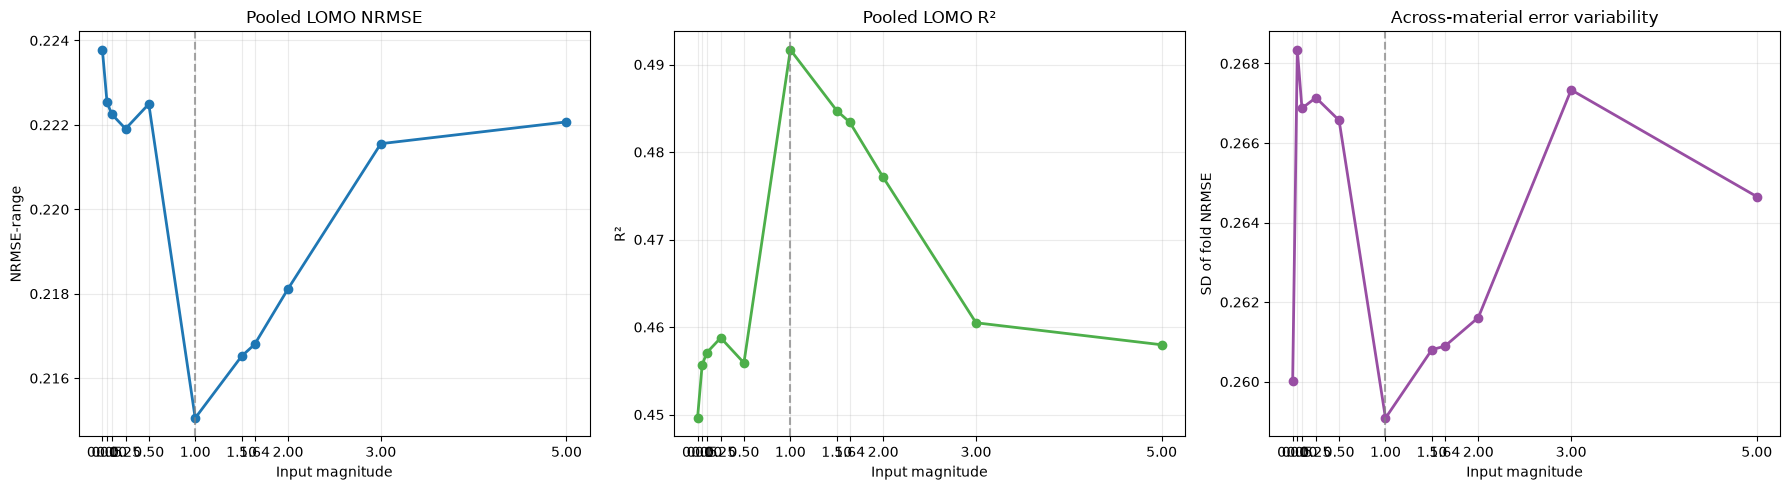

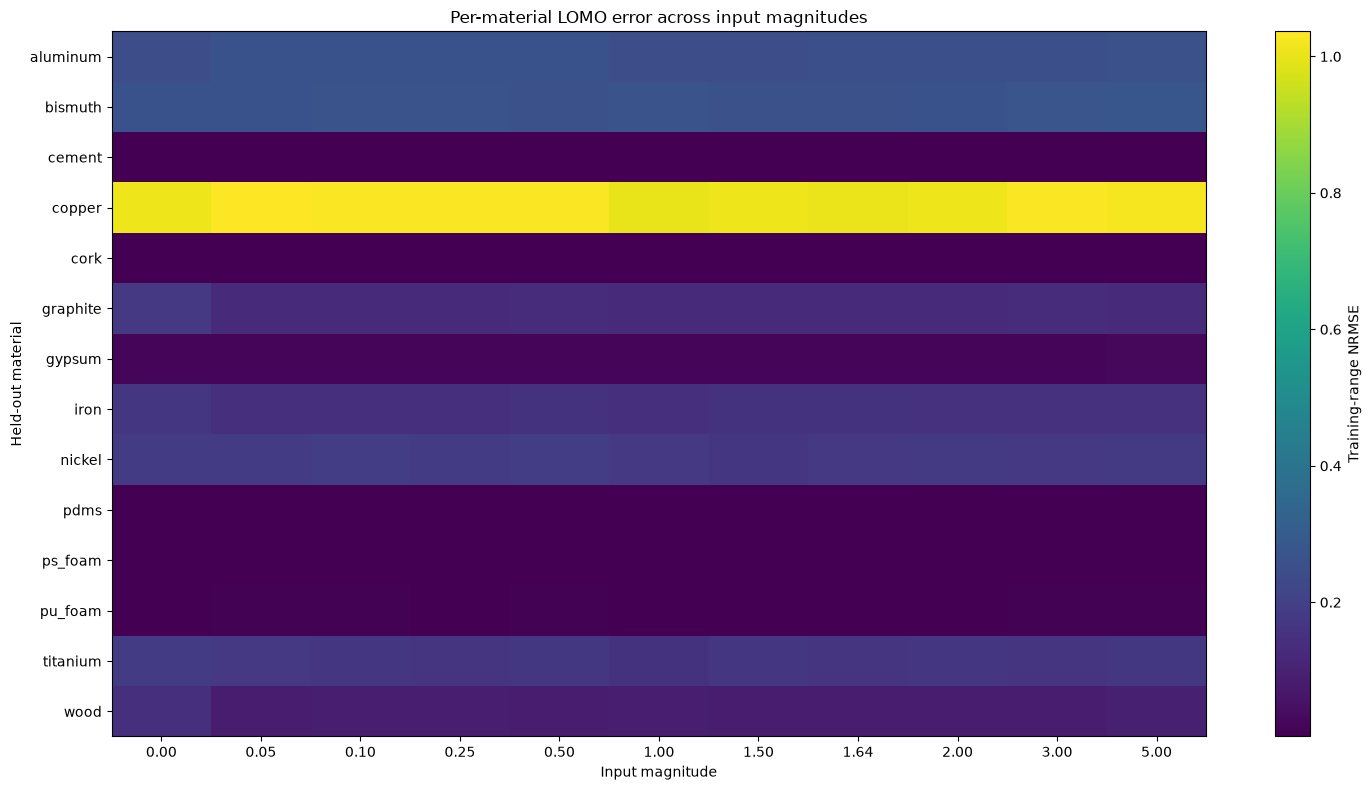

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(OVERALL["input_magnitude"], OVERALL["nrmse_range"], "o-", linewidth=2)
axes[0].set(title="Pooled LOMO NRMSE", ylabel="NRMSE-range")
axes[1].plot(OVERALL["input_magnitude"], OVERALL["r2"], "o-", color="#4daf4a", linewidth=2)
axes[1].set(title="Pooled LOMO R²", ylabel="R²")
axes[2].plot(OVERALL["input_magnitude"], OVERALL["fold_nrmse_sd"], "o-", color="#984ea3", linewidth=2)
axes[2].set(title="Across-material error variability", ylabel="SD of fold NRMSE")
for ax in axes:
    ax.set_xlabel("Input magnitude")
    ax.axvline(best["input_magnitude"], color="gray", linestyle="--", alpha=.7)
    ax.set_xticks(INPUT_MAGNITUDE_VALUES)
    ax.grid(alpha=.25)
plt.tight_layout()
plt.show()

heatmap = FOLD_METRICS.pivot(
    index="held_out_material", columns="input_magnitude", values="nrmse_training_range"
)[list(INPUT_MAGNITUDE_VALUES)]
fig, ax = plt.subplots(figsize=(15, 8))
image = ax.imshow(heatmap, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(heatmap.columns)), [f"{x:.2f}" for x in heatmap.columns])
ax.set_yticks(range(len(heatmap.index)), heatmap.index)
ax.set_xlabel("Input magnitude")
ax.set_ylabel("Held-out material")
ax.set_title("Per-material LOMO error across input magnitudes")
fig.colorbar(image, ax=ax, label="Training-range NRMSE")
plt.tight_layout()
plt.show()


# 9. Prediction behavior for customizable case-study materials


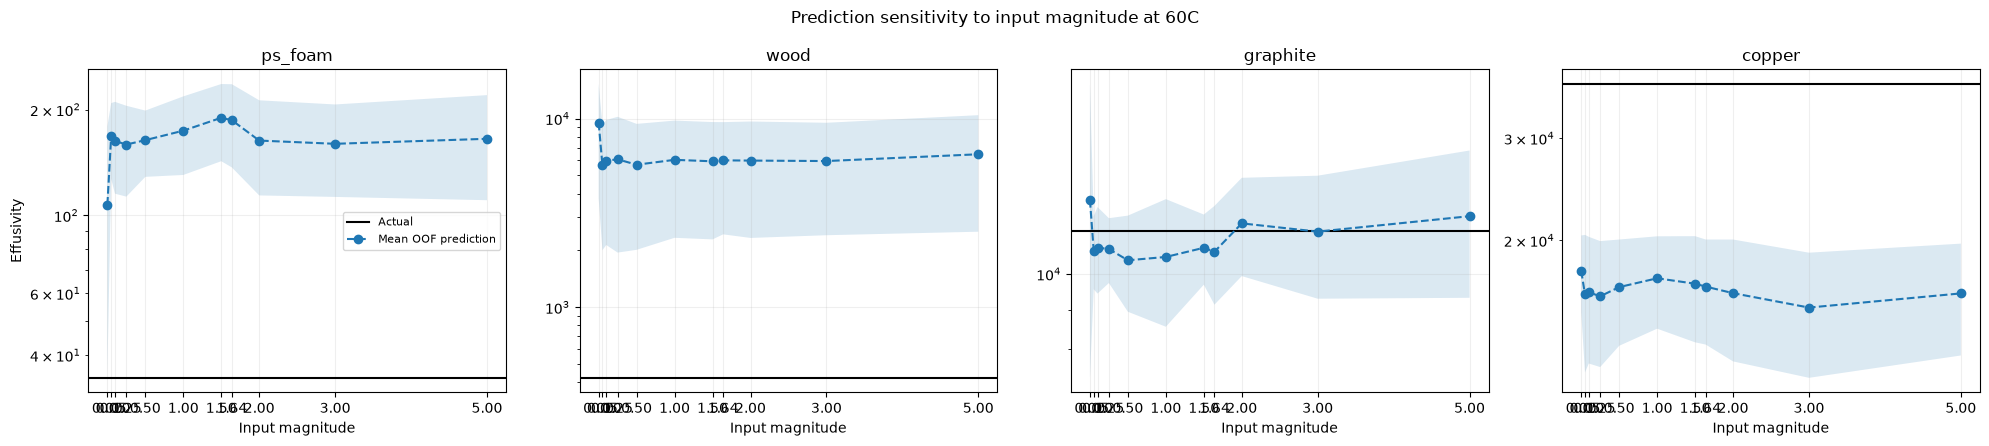

In [10]:
CASE_STUDY_TEMPERATURE = "60C"
CASE_STUDY_MATERIALS = ["ps_foam", "wood", "graphite", "copper"]

case = (
    OOF[(OOF["Temperature"] == CASE_STUDY_TEMPERATURE) & OOF["Sample"].isin(CASE_STUDY_MATERIALS)]
    .groupby(["input_magnitude", "Sample"], as_index=False)
    .agg(y_true=("y_true", "mean"), y_pred=("y_pred", "mean"), prediction_sd=("y_pred", "std"))
)

fig, axes = plt.subplots(1, len(CASE_STUDY_MATERIALS), figsize=(20, 4.5), sharex=True)
for ax, material in zip(axes, CASE_STUDY_MATERIALS):
    part = case[case["Sample"] == material].sort_values("input_magnitude")
    if part.empty:
        ax.set_visible(False)
        continue
    ax.axhline(part["y_true"].iloc[0], color="black", label="Actual")
    ax.plot(part["input_magnitude"], part["y_pred"], "o--", label="Mean OOF prediction")
    ax.fill_between(
        part["input_magnitude"], part["y_pred"] - part["prediction_sd"],
        part["y_pred"] + part["prediction_sd"], alpha=.16,
    )
    ax.set_yscale("log")
    ax.set_title(material)
    ax.set_xlabel("Input magnitude")
    ax.set_xticks(INPUT_MAGNITUDE_VALUES)
    ax.grid(alpha=.2)
axes[0].set_ylabel("Effusivity")
axes[0].legend(fontsize=8)
fig.suptitle(f"Prediction sensitivity to input magnitude at {CASE_STUDY_TEMPERATURE}")
plt.tight_layout()
plt.show()


# 10. Collective ESN dynamics across selected input magnitudes


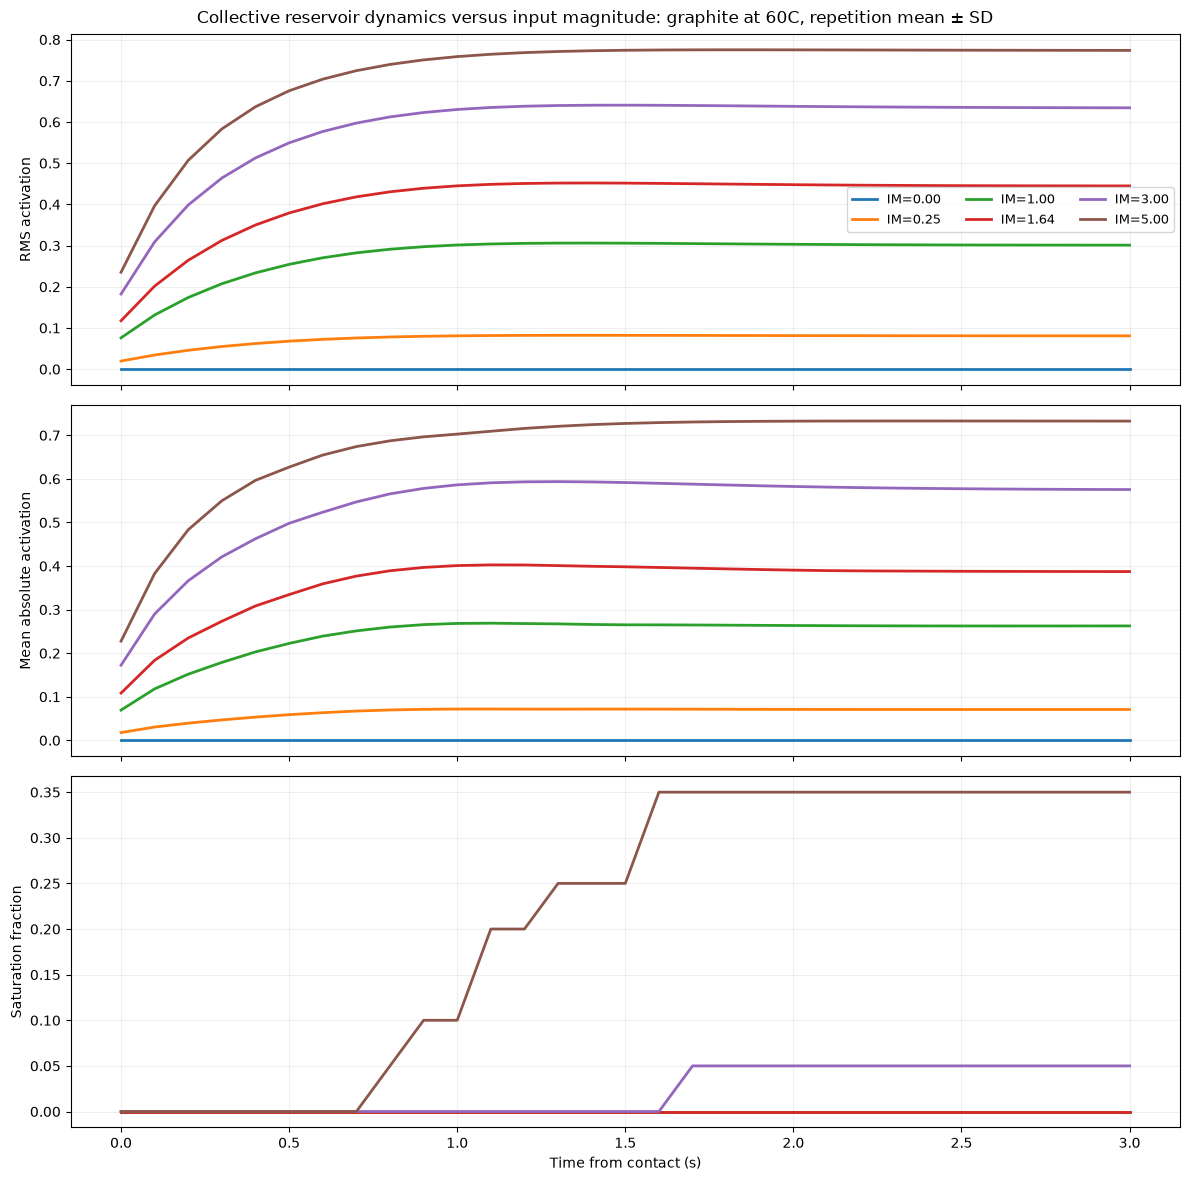

In [11]:
DYNAMICS_MATERIAL = "graphite"
DYNAMICS_TEMPERATURE = "60C"
DYNAMICS_INPUT_MAGNITUDES = (0.00, 0.25, 1.00, 1.64, 3.00, 5.00)
DYNAMICS_SEED = 42

selected = METADATA[
    (METADATA["Sample"] == DYNAMICS_MATERIAL)
    & (METADATA["Temperature"] == DYNAMICS_TEMPERATURE)
].sort_values("Trial")
if selected.empty:
    raise KeyError("Requested dynamics material/temperature was not found.")

common_time = np.linspace(*ANALYSIS_WINDOW, 61)
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for input_magnitude in DYNAMICS_INPUT_MAGNITUDES:
    if input_magnitude not in INPUT_MAGNITUDE_VALUES:
        raise KeyError(f"IM={input_magnitude} was not declared in INPUT_MAGNITUDE_VALUES.")
    reservoir = ManualReservoir(input_magnitude=input_magnitude, random_state=DYNAMICS_SEED)
    rms_trials, mean_abs_trials, saturation_trials = [], [], []
    for trial_id in selected["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        rms_trials.append(np.interp(common_time, state_time, np.sqrt(np.mean(states ** 2, axis=1))))
        mean_abs_trials.append(np.interp(common_time, state_time, np.mean(np.abs(states), axis=1)))
        saturation_trials.append(np.interp(common_time, state_time, np.mean(np.abs(states) >= .95, axis=1)))

    for ax, trials, label in zip(
        axes, (rms_trials, mean_abs_trials, saturation_trials),
        ("RMS activation", "Mean absolute activation", "Saturation fraction"),
    ):
        trials = np.asarray(trials)
        mean, sd = trials.mean(axis=0), trials.std(axis=0, ddof=1)
        ax.plot(common_time, mean, linewidth=2, label=f"IM={input_magnitude:.2f}")
        ax.fill_between(common_time, mean - sd, mean + sd, alpha=.10)
        ax.set_ylabel(label)
        ax.grid(alpha=.2)

axes[-1].set_xlabel("Time from contact (s)")
axes[0].legend(ncol=3, fontsize=9)
fig.suptitle(
    f"Collective reservoir dynamics versus input magnitude: {DYNAMICS_MATERIAL} at "
    f"{DYNAMICS_TEMPERATURE}, repetition mean ± SD"
)
plt.tight_layout()
plt.show()


# 11. Explicit input-magnitude → ESN-dynamics relationship

The same physical input and reservoir realization are used across columns. Only the multiplier
applied to the fixed random input-weight matrix changes, so matched units can be compared.

Input magnitude scales both the bias and measured-input connections in this implementation.
Therefore, the zero condition is a no-`Win` reference: neither the bias nor `P + dP/dt` enters
through `Win`, and the zero initial state remains zero. Increasing the value strengthens the
pre-activation supplied to `tanh`; sufficiently large values can increase nonlinear separation
but may also compress states near ±1.


/Users/markkeanujamesexconde/.virtualenvs/warmth-sensor-object-detection/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/markkeanujamesexconde/.virtualenvs/warmth-sensor-object-detection/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,input_magnitude,input_weight_scaling_factor,mean_state_step_magnitude,mean_lag1_state_correlation,mean_max_abs_input_state_correlation,mean_absolute_activation
0,0.00,0.00,0.000000,NaN,NaN,0.000000
1,0.25,0.25,0.001518,0.994546,0.826146,0.065322
2,1.00,1.00,0.005393,0.994789,0.821207,0.243496
3,1.64,1.64,0.007547,0.995876,0.841530,0.363754
4,3.00,3.00,0.009957,0.994572,0.818198,0.540756
5,5.00,5.00,0.011231,0.996500,0.837429,0.676167


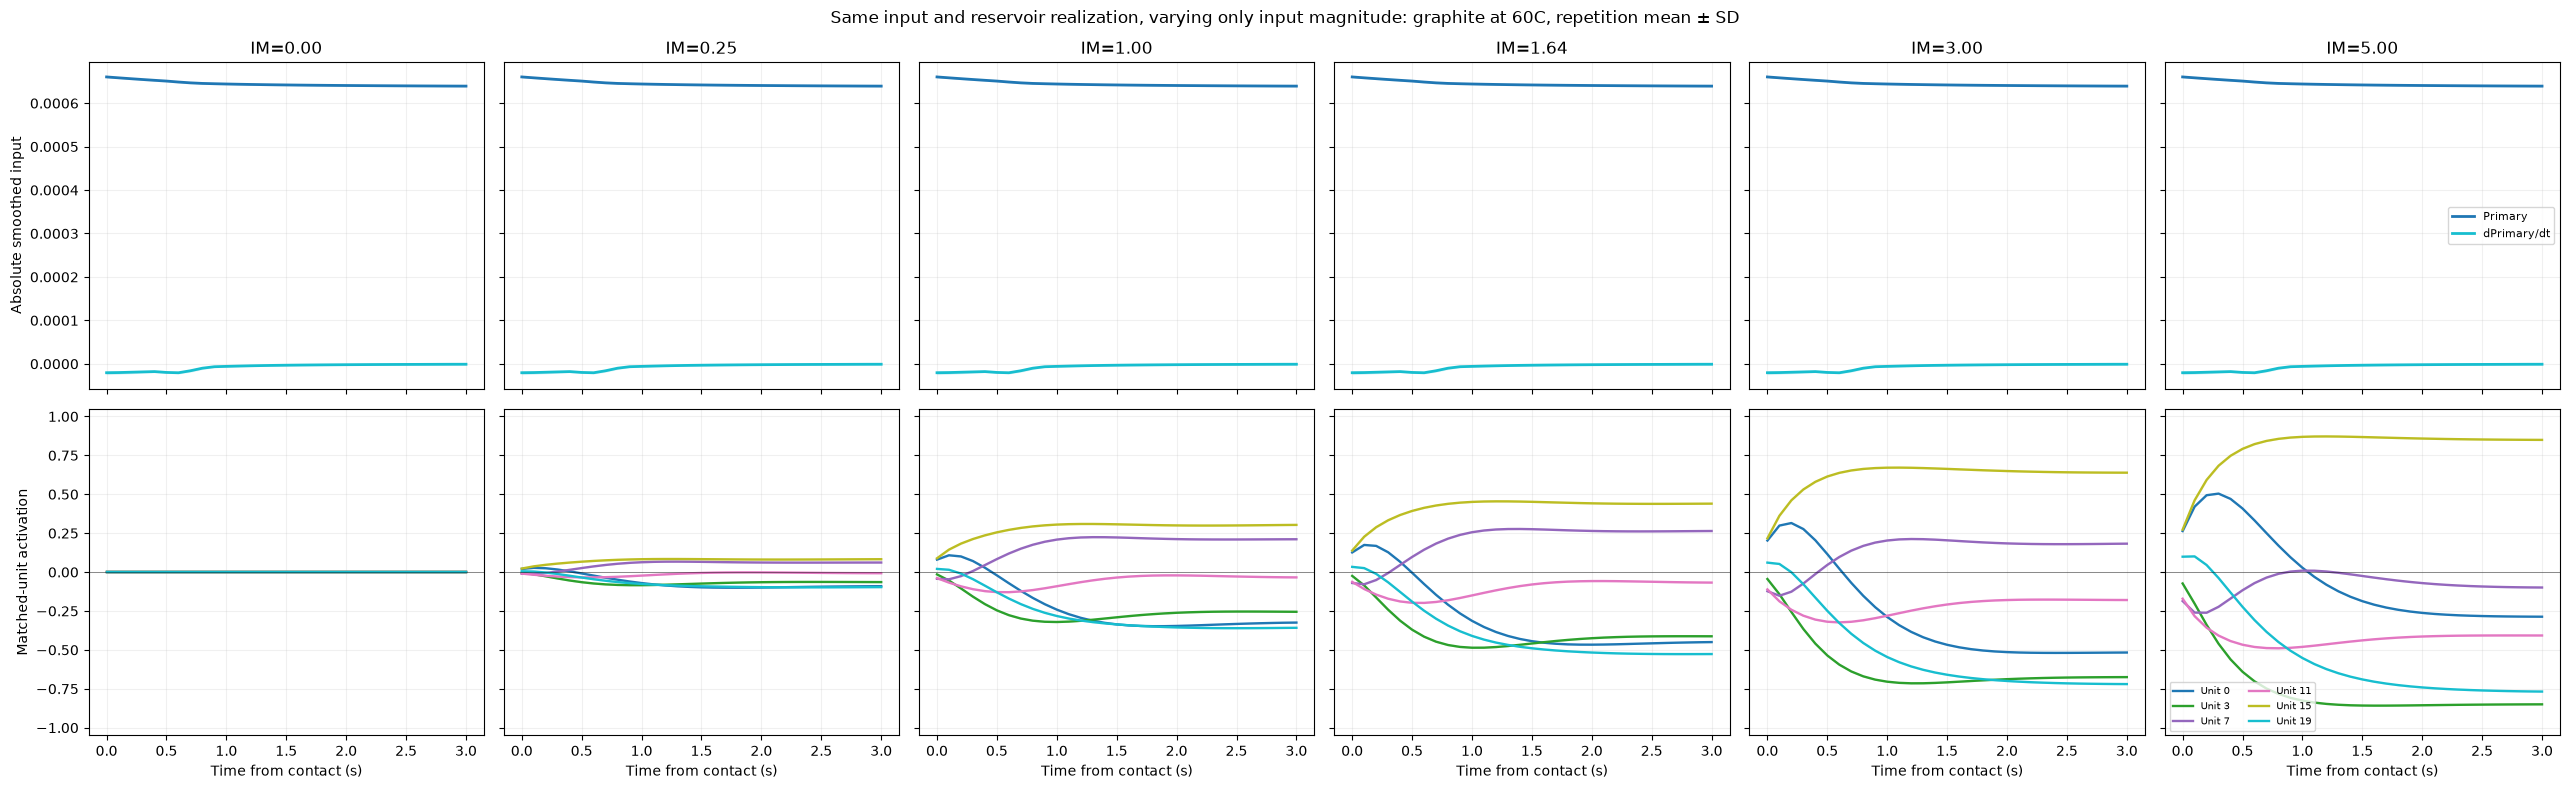

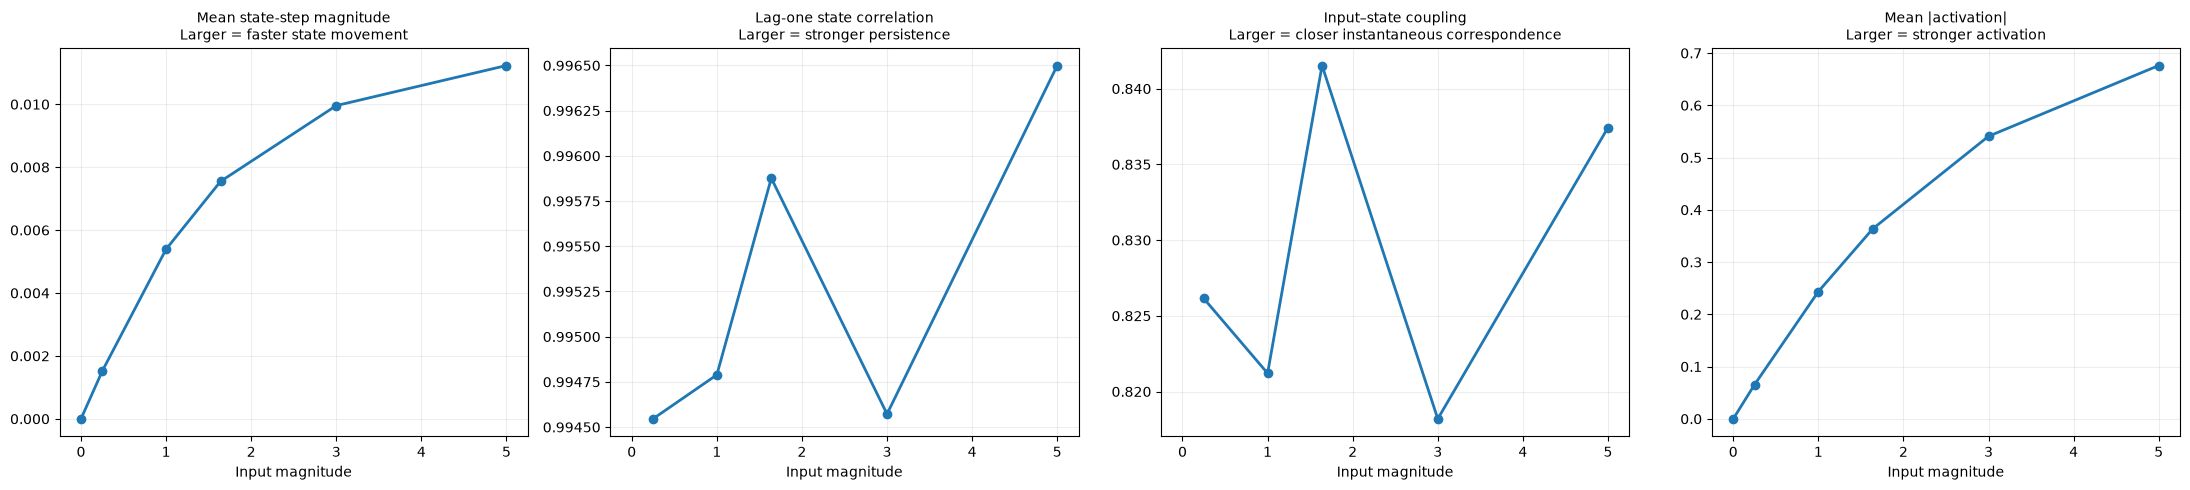

In [12]:
RELATIONSHIP_INPUT_MAGNITUDES = DYNAMICS_INPUT_MAGNITUDES
RELATIONSHIP_UNITS = (0, 3, 7, 11, 15, 19)

if any(unit >= FIXED_ESN_PARAMS["res_size"] for unit in RELATIONSHIP_UNITS):
    raise IndexError("RELATIONSHIP_UNITS contains an index outside the fixed reservoir.")


def resample_trial_input_and_states(trial_id, input_magnitude, seed, target_time):
    trial = aligned_trials[trial_id]
    time_values = trial["time_from_contact"].to_numpy(float)
    inputs = esn_input(trial)
    reservoir = ManualReservoir(input_magnitude=input_magnitude, random_state=seed)
    states = reservoir.run(inputs)
    state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
    input_resampled = np.column_stack([
        np.interp(target_time, time_values, inputs[:, channel])
        for channel in range(inputs.shape[1])
    ])
    state_resampled = np.column_stack([
        np.interp(target_time, state_time, states[:, unit])
        for unit in range(states.shape[1])
    ])
    return input_resampled, state_resampled


RELATIONSHIP_INPUT_CUBES, RELATIONSHIP_STATE_CUBES, relationship_rows = {}, {}, []
for input_magnitude in RELATIONSHIP_INPUT_MAGNITUDES:
    input_repetitions, state_repetitions = [], []
    for trial_id in selected["trial_id"]:
        inputs, states = resample_trial_input_and_states(
            trial_id, input_magnitude, DYNAMICS_SEED, common_time
        )
        input_repetitions.append(inputs); state_repetitions.append(states)
    input_cube, state_cube = np.asarray(input_repetitions), np.asarray(state_repetitions)
    RELATIONSHIP_INPUT_CUBES[input_magnitude] = input_cube
    RELATIONSHIP_STATE_CUBES[input_magnitude] = state_cube
    mean_inputs, mean_states = input_cube.mean(axis=0), state_cube.mean(axis=0)
    lag_correlations, couplings = [], []
    for unit in range(mean_states.shape[1]):
        previous, current = mean_states[:-1, unit], mean_states[1:, unit]
        if np.std(previous) > 1e-12 and np.std(current) > 1e-12:
            lag_correlations.append(float(np.corrcoef(previous, current)[0, 1]))
        channel_values = []
        for channel in range(mean_inputs.shape[1]):
            if np.std(mean_states[:, unit]) > 1e-12 and np.std(mean_inputs[:, channel]) > 1e-12:
                channel_values.append(abs(float(np.corrcoef(mean_inputs[:, channel], mean_states[:, unit])[0, 1])))
        if channel_values:
            couplings.append(max(channel_values))
    relationship_rows.append({
        "input_magnitude": float(input_magnitude),
        "input_weight_scaling_factor": float(input_magnitude),
        "mean_state_step_magnitude": float(np.mean(np.abs(np.diff(mean_states, axis=0)))),
        "mean_lag1_state_correlation": float(np.mean(lag_correlations)),
        "mean_max_abs_input_state_correlation": float(np.mean(couplings)),
        "mean_absolute_activation": float(np.mean(np.abs(state_cube))),
    })

INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP = pd.DataFrame(relationship_rows)
display(INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP)

fig, axes = plt.subplots(2, len(RELATIONSHIP_INPUT_MAGNITUDES), figsize=(4.3*len(RELATIONSHIP_INPUT_MAGNITUDES), 8), sharex=True, sharey="row")
unit_colors = plt.cm.tab10(np.linspace(0, 1, len(RELATIONSHIP_UNITS)))
for column, input_magnitude in enumerate(RELATIONSHIP_INPUT_MAGNITUDES):
    input_cube = RELATIONSHIP_INPUT_CUBES[input_magnitude]
    state_cube = RELATIONSHIP_STATE_CUBES[input_magnitude]
    input_mean, input_sd = input_cube.mean(axis=0), input_cube.std(axis=0, ddof=1)
    state_mean, state_sd = state_cube.mean(axis=0), state_cube.std(axis=0, ddof=1)
    top, bottom = axes[0, column], axes[1, column]
    for channel, label, color in ((0, "Primary", "#1f77b4"), (1, "dPrimary/dt", "#17becf")):
        top.plot(common_time, input_mean[:, channel], color=color, linewidth=2, label=label)
        top.fill_between(common_time, input_mean[:, channel]-input_sd[:, channel], input_mean[:, channel]+input_sd[:, channel], color=color, alpha=.12)
    top.set_title(f"IM={input_magnitude:.2f}")
    top.grid(alpha=.18)
    for color, unit in zip(unit_colors, RELATIONSHIP_UNITS):
        bottom.plot(common_time, state_mean[:, unit], color=color, linewidth=1.7, label=f"Unit {unit}")
        bottom.fill_between(common_time, state_mean[:, unit]-state_sd[:, unit], state_mean[:, unit]+state_sd[:, unit], color=color, alpha=.08)
    bottom.axhline(0, color="black", linewidth=.6, alpha=.5)
    bottom.set_ylim(-1.05, 1.05); bottom.set_xlabel("Time from contact (s)"); bottom.grid(alpha=.18)
axes[0, 0].set_ylabel("Absolute smoothed input")
axes[1, 0].set_ylabel("Matched-unit activation")
axes[0, -1].legend(fontsize=8); axes[1, -1].legend(fontsize=7, ncol=2)
fig.suptitle(f"Same input and reservoir realization, varying only input magnitude: {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}, repetition mean ± SD")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharex=True)
diagnostics = (
    ("mean_state_step_magnitude", "Mean state-step magnitude", "Larger = faster state movement"),
    ("mean_lag1_state_correlation", "Lag-one state correlation", "Larger = stronger persistence"),
    ("mean_max_abs_input_state_correlation", "Input–state coupling", "Larger = closer instantaneous correspondence"),
    ("mean_absolute_activation", "Mean |activation|", "Larger = stronger activation"),
)
for ax, (column, title, subtitle) in zip(axes, diagnostics):
    ax.plot(INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP["input_magnitude"], INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP[column], "o-", linewidth=2)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10); ax.set_xlabel("Input magnitude"); ax.grid(alpha=.22)
plt.tight_layout(); plt.show()


# 12. Unit-level trajectories, heatmaps, and dynamic-complexity diagnostics

Reservoir size, recurrent weights, leak rate, spectral radius, seed, and physical inputs are fixed;
only the input-weight magnitude changes. Corresponding unit indices can therefore be followed
across conditions. The panels show all 20 mean trajectories, state and repetition-SD heatmaps,
redundancy, effective rank, temporal variation, repeatability, and saturation.


,input_magnitude,n_repetitions,mean_abs_unit_correlation,effective_rank,effective_rank_fraction,pca_dimensions_95pct,pca95_fraction_of_units,mean_unit_temporal_sd,mean_repetition_sd,saturation_fraction,mean_absolute_activation
0,0.00,6,NaN,0.000000,0.000000,0,0.0,0.000000,0.000000,0.000000,0.000000
1,0.25,6,0.700305,1.737469,0.086873,2,0.1,0.019961,0.000003,0.000000,0.065322
2,1.00,6,0.720674,1.676198,0.083810,2,0.1,0.071760,0.000009,0.000000,0.243496
3,1.64,6,0.742253,1.603710,0.080185,2,0.1,0.101181,0.000008,0.000000,0.363754
4,3.00,6,0.719581,1.534208,0.076710,2,0.1,0.132298,0.000009,0.022131,0.540756
5,5.00,6,0.831530,1.492594,0.074630,2,0.1,0.148025,0.000008,0.216393,0.676167


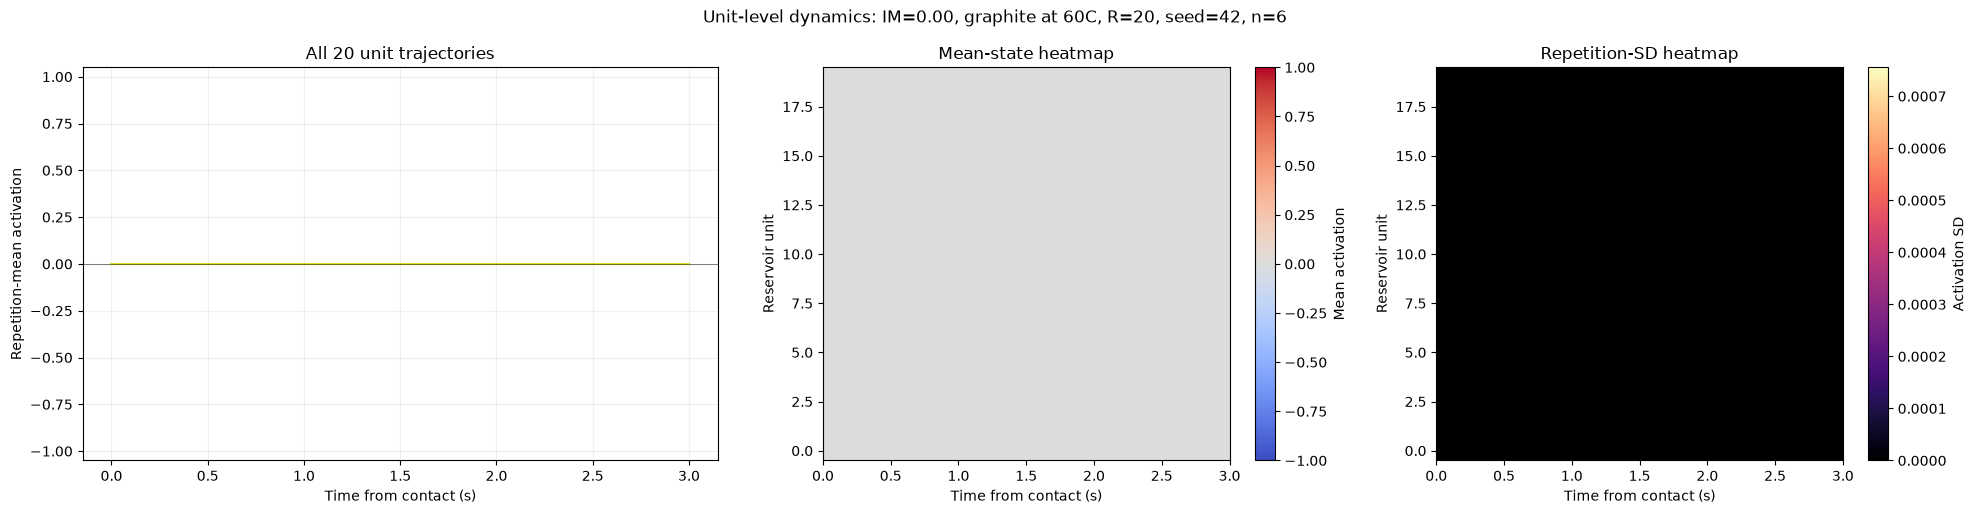

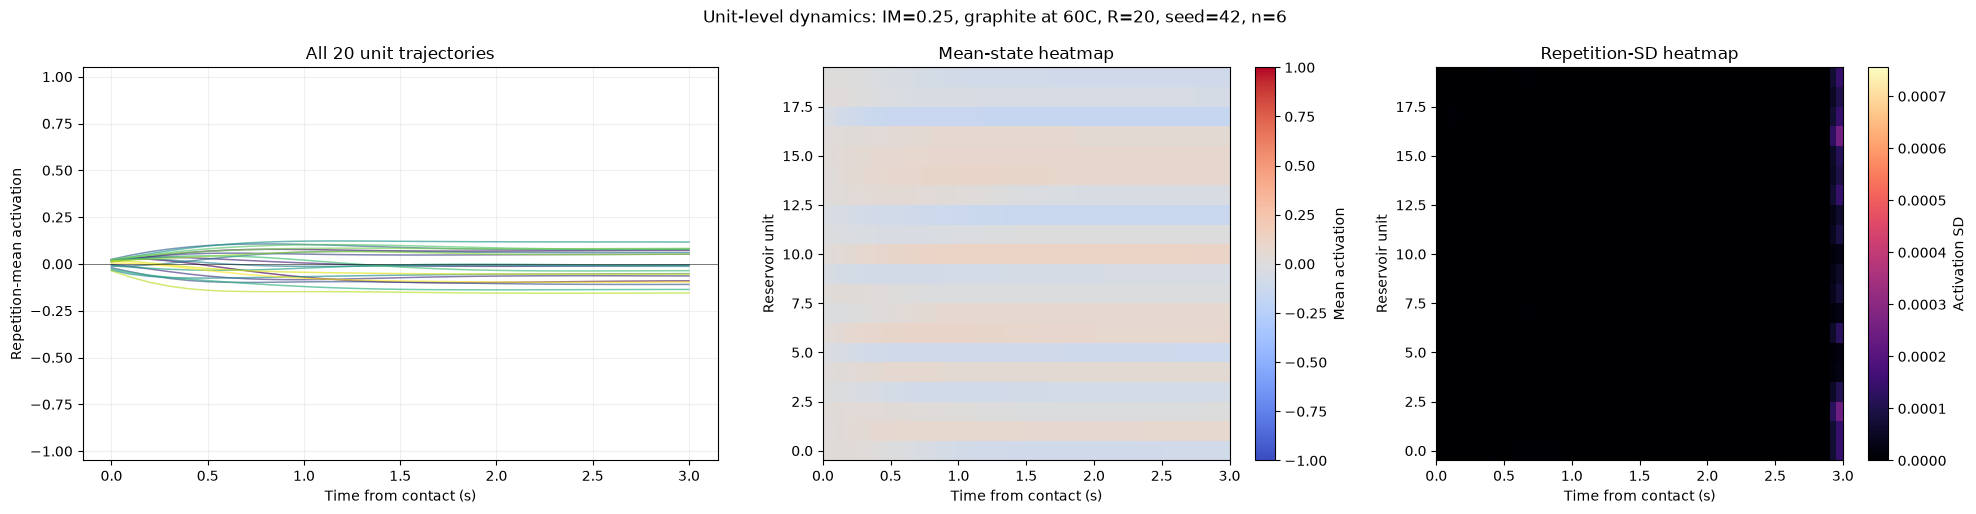

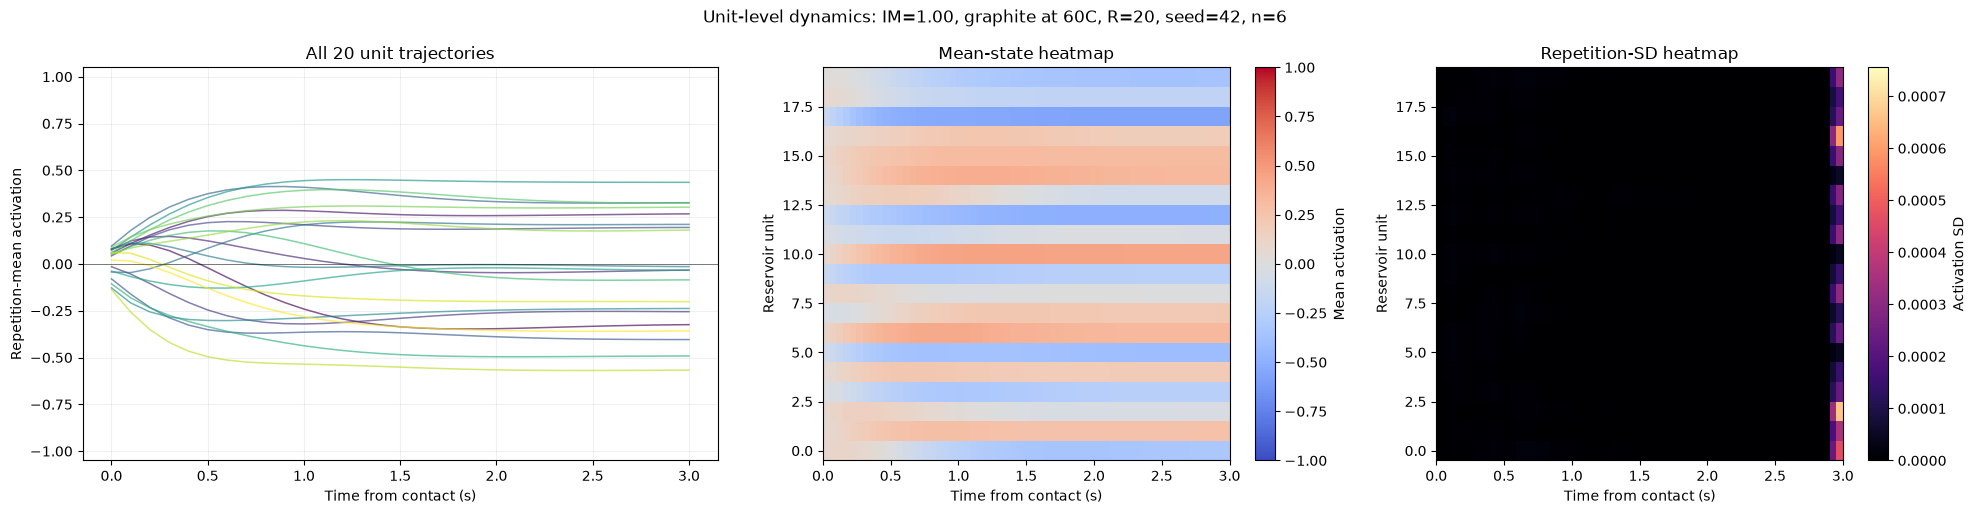

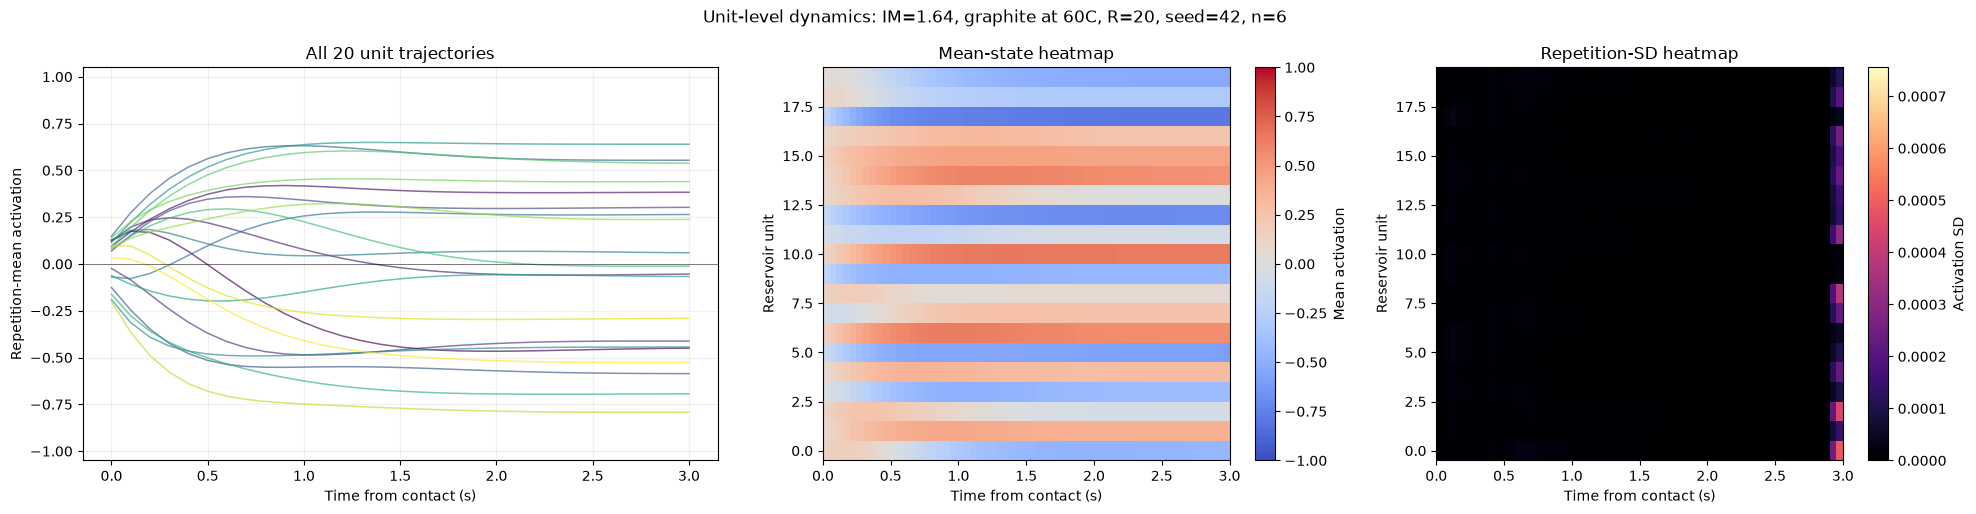

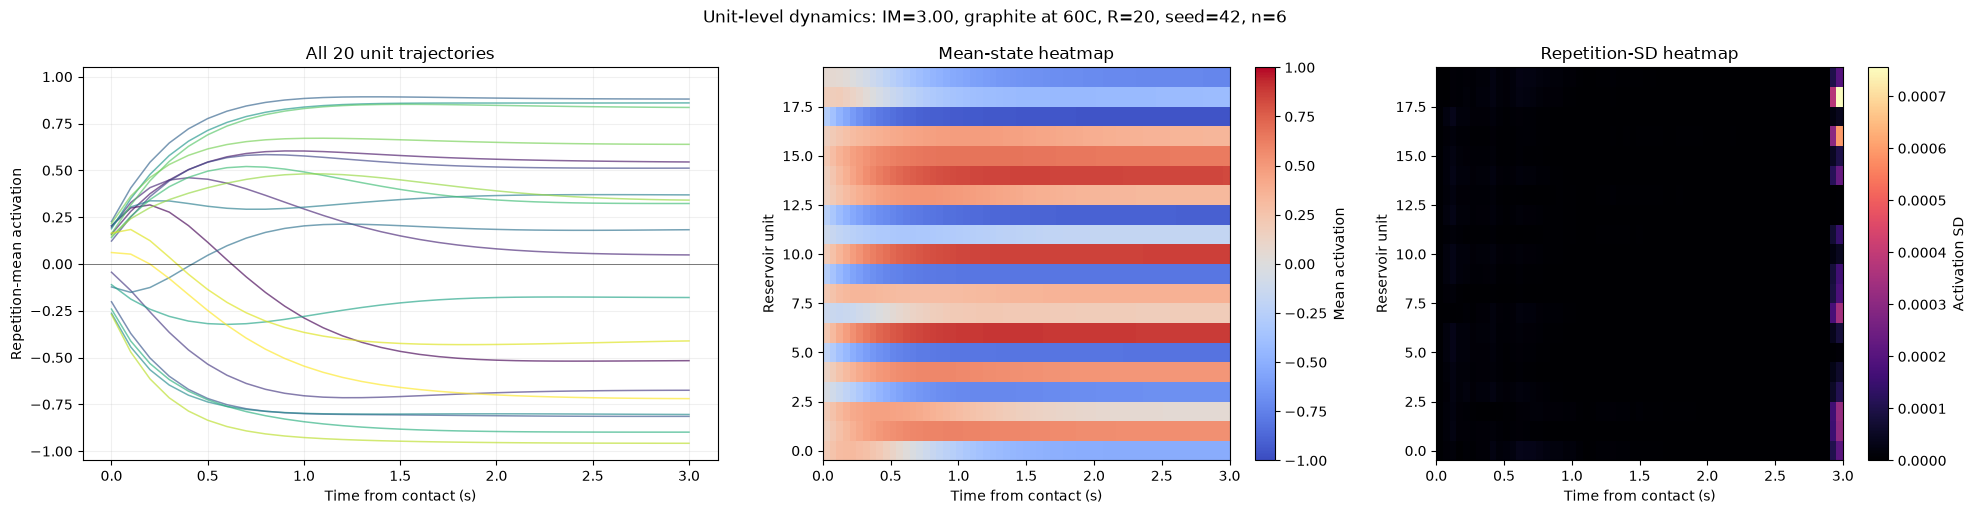

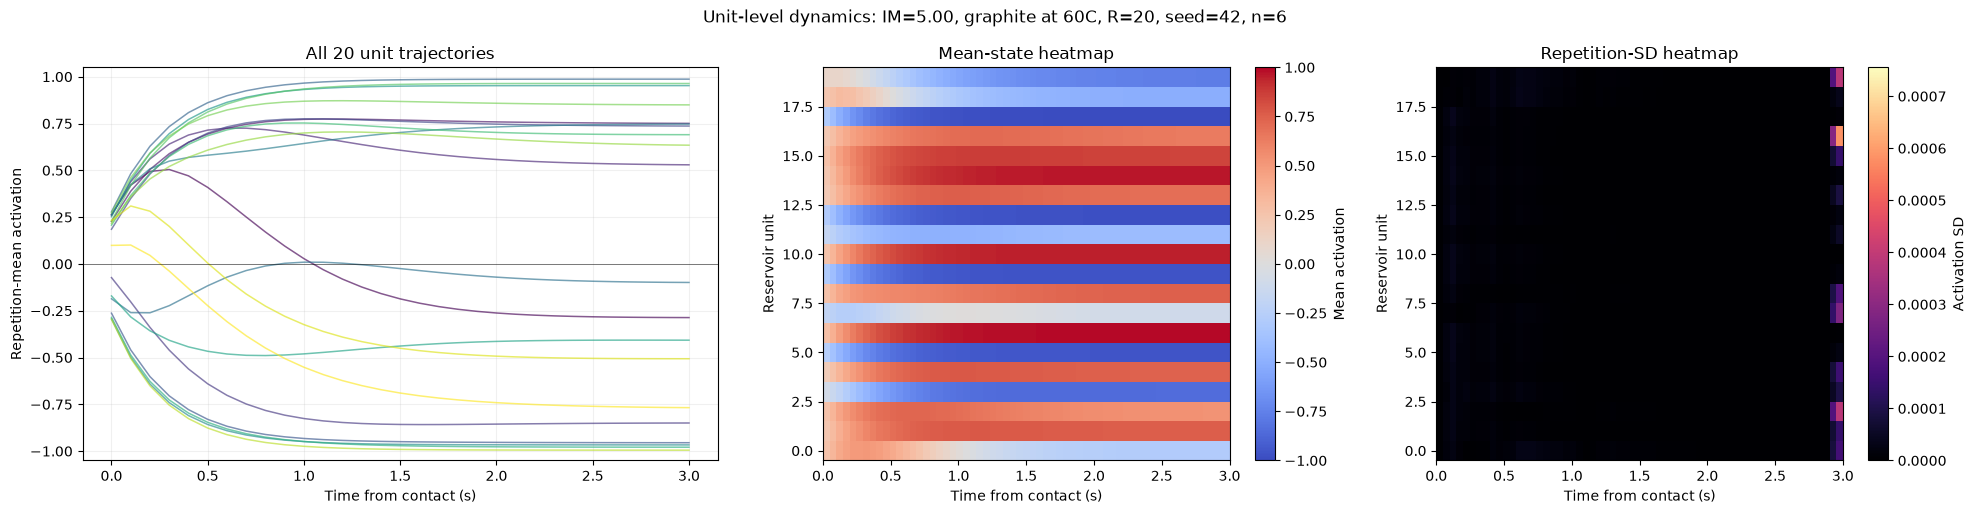

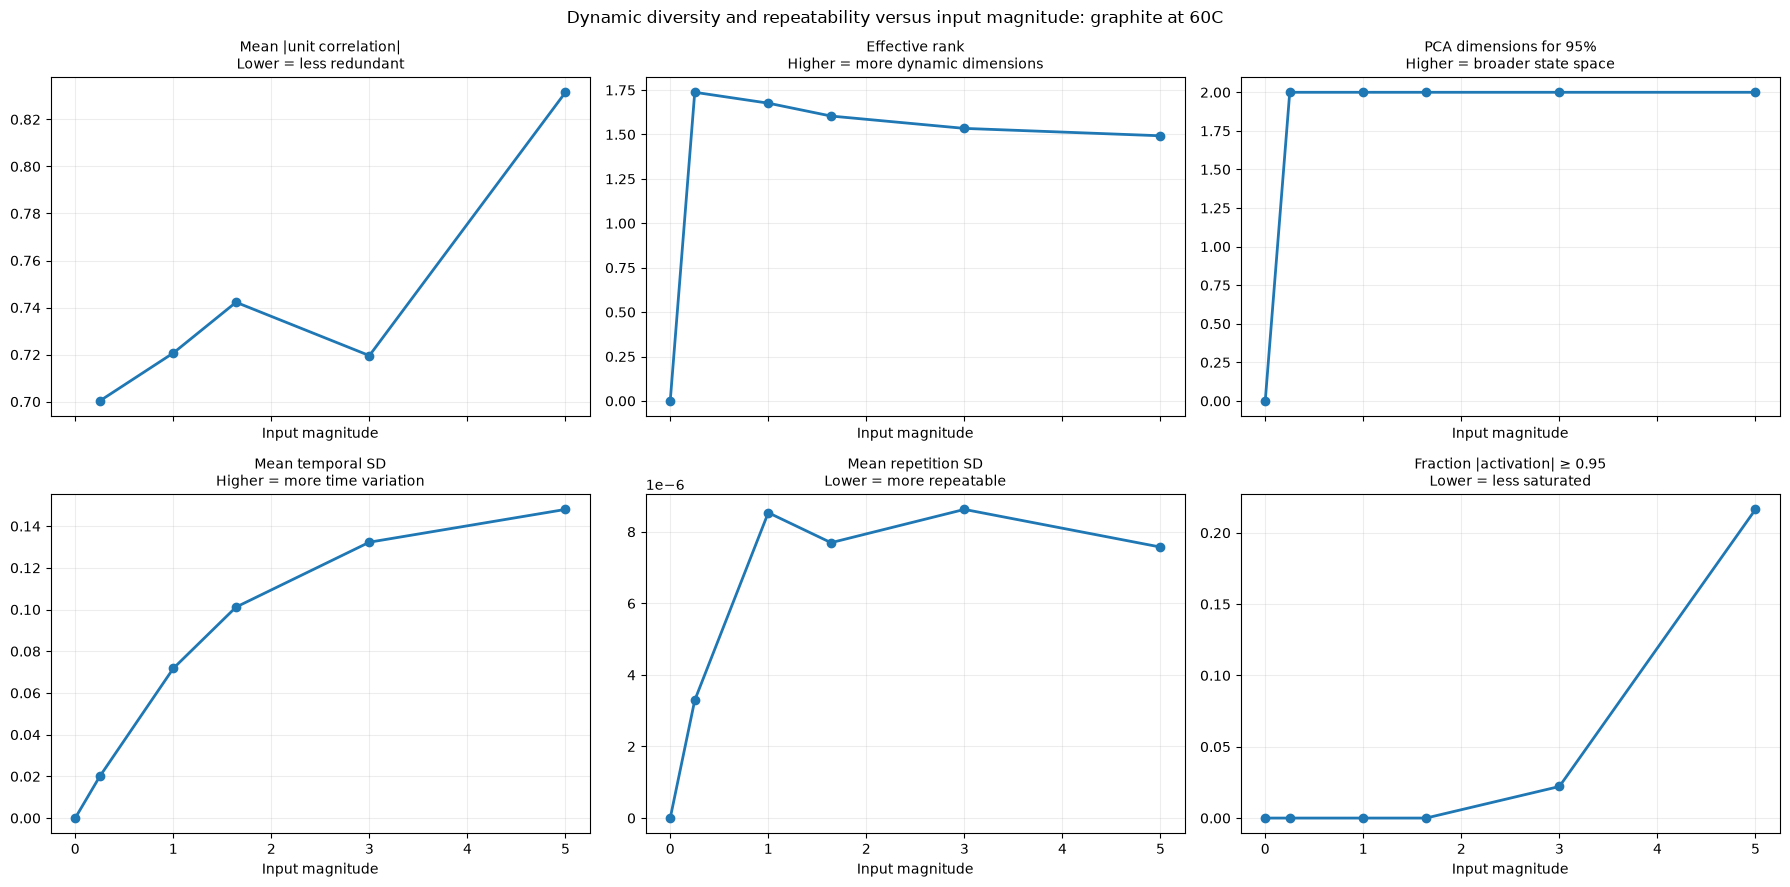

In [13]:
SATURATION_THRESHOLD = 0.95
PCA_VARIANCE_THRESHOLD = 0.95


def collect_resampled_states(input_magnitude, selected_metadata, seed, target_time):
    reservoir = ManualReservoir(input_magnitude=input_magnitude, random_state=seed)
    repetitions, trial_ids = [], []
    for trial_id in selected_metadata["trial_id"]:
        trial = aligned_trials[trial_id]
        time_values = trial["time_from_contact"].to_numpy(float)
        states = reservoir.run(esn_input(trial))
        state_time = time_values[FIXED_ESN_PARAMS["washout"]:]
        repetitions.append(np.column_stack([
            np.interp(target_time, state_time, states[:, unit])
            for unit in range(states.shape[1])
        ]))
        trial_ids.append(trial_id)
    return np.asarray(repetitions), trial_ids


def state_complexity_metrics(state_cube, input_magnitude):
    state_cube = np.asarray(state_cube, float)
    repetition_mean = state_cube.mean(axis=0)
    centered = repetition_mean - repetition_mean.mean(axis=0, keepdims=True)
    valid = np.std(repetition_mean, axis=0) > 1e-12
    if valid.sum() >= 2:
        correlation = np.corrcoef(repetition_mean[:, valid], rowvar=False)
        off_diagonal = correlation[np.triu_indices_from(correlation, k=1)]
        mean_abs_correlation = float(np.nanmean(np.abs(off_diagonal)))
    else:
        mean_abs_correlation = np.nan
    singular_values = np.linalg.svd(centered, full_matrices=False, compute_uv=False)
    singular_values = singular_values[singular_values > 1e-12]
    if len(singular_values):
        energy_fraction = singular_values ** 2 / np.sum(singular_values ** 2)
        effective_rank = float(np.exp(-np.sum(energy_fraction * np.log(energy_fraction))))
        pca_dimensions_95 = int(np.searchsorted(np.cumsum(energy_fraction), PCA_VARIANCE_THRESHOLD) + 1)
    else:
        effective_rank, pca_dimensions_95 = 0.0, 0
    repetition_sd = state_cube.std(axis=0, ddof=1) if len(state_cube) > 1 else np.zeros_like(repetition_mean)
    return {
        "input_magnitude": float(input_magnitude), "n_repetitions": int(len(state_cube)),
        "mean_abs_unit_correlation": mean_abs_correlation,
        "effective_rank": effective_rank,
        "effective_rank_fraction": effective_rank / min(repetition_mean.shape),
        "pca_dimensions_95pct": pca_dimensions_95,
        "pca95_fraction_of_units": pca_dimensions_95 / FIXED_ESN_PARAMS["res_size"],
        "mean_unit_temporal_sd": float(np.mean(repetition_mean.std(axis=0, ddof=0))),
        "mean_repetition_sd": float(np.mean(repetition_sd)),
        "saturation_fraction": float(np.mean(np.abs(state_cube) >= SATURATION_THRESHOLD)),
        "mean_absolute_activation": float(np.mean(np.abs(state_cube))),
    }


UNIT_STATE_CUBES, UNIT_STATE_TRIAL_IDS, rows = {}, {}, []
for input_magnitude in DYNAMICS_INPUT_MAGNITUDES:
    cube, trial_ids = collect_resampled_states(input_magnitude, selected, DYNAMICS_SEED, common_time)
    UNIT_STATE_CUBES[input_magnitude] = cube
    UNIT_STATE_TRIAL_IDS[input_magnitude] = trial_ids
    rows.append(state_complexity_metrics(cube, input_magnitude))
DYNAMICS_COMPLEXITY = pd.DataFrame(rows)
display(DYNAMICS_COMPLEXITY)

all_sd = [cube.std(axis=0, ddof=1) for cube in UNIT_STATE_CUBES.values()]
sd_color_max = max(float(np.nanmax(x)) for x in all_sd)
if not np.isfinite(sd_color_max) or np.isclose(sd_color_max, 0):
    sd_color_max = 1.0

res_size = FIXED_ESN_PARAMS["res_size"]
for input_magnitude in DYNAMICS_INPUT_MAGNITUDES:
    cube = UNIT_STATE_CUBES[input_magnitude]
    mean_states = cube.mean(axis=0)
    sd_states = cube.std(axis=0, ddof=1)
    fig, axes = plt.subplots(1, 3, figsize=(20, 5.2), gridspec_kw={"width_ratios": [1.25, 1, 1]})
    colors = plt.cm.viridis(np.linspace(0, 1, res_size))
    for unit in range(res_size):
        axes[0].plot(common_time, mean_states[:, unit], color=colors[unit], linewidth=1.1, alpha=.65)
    axes[0].axhline(0, color="black", linewidth=.7, alpha=.5)
    axes[0].set(title=f"All {res_size} unit trajectories", xlabel="Time from contact (s)", ylabel="Repetition-mean activation", ylim=(-1.05, 1.05))
    axes[0].grid(alpha=.18)
    im0 = axes[1].imshow(mean_states.T, aspect="auto", origin="lower", extent=[common_time[0], common_time[-1], -.5, res_size-.5], cmap="coolwarm", vmin=-1, vmax=1, interpolation="nearest")
    axes[1].set(title="Mean-state heatmap", xlabel="Time from contact (s)", ylabel="Reservoir unit")
    fig.colorbar(im0, ax=axes[1], label="Mean activation")
    im1 = axes[2].imshow(sd_states.T, aspect="auto", origin="lower", extent=[common_time[0], common_time[-1], -.5, res_size-.5], cmap="magma", vmin=0, vmax=sd_color_max, interpolation="nearest")
    axes[2].set(title="Repetition-SD heatmap", xlabel="Time from contact (s)", ylabel="Reservoir unit")
    fig.colorbar(im1, ax=axes[2], label="Activation SD")
    fig.suptitle(f"Unit-level dynamics: IM={input_magnitude:.2f}, {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}, R={res_size}, seed={DYNAMICS_SEED}, n={len(cube)}")
    plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharex=True)
diagnostics = (
    ("mean_abs_unit_correlation", "Mean |unit correlation|", "Lower = less redundant"),
    ("effective_rank", "Effective rank", "Higher = more dynamic dimensions"),
    ("pca_dimensions_95pct", "PCA dimensions for 95%", "Higher = broader state space"),
    ("mean_unit_temporal_sd", "Mean temporal SD", "Higher = more time variation"),
    ("mean_repetition_sd", "Mean repetition SD", "Lower = more repeatable"),
    ("saturation_fraction", "Fraction |activation| ≥ 0.95", "Lower = less saturated"),
)
for ax, (column, title, subtitle) in zip(axes.ravel(), diagnostics):
    ax.plot(DYNAMICS_COMPLEXITY["input_magnitude"], DYNAMICS_COMPLEXITY[column], "o-", linewidth=2)
    ax.set_title(f"{title}\n{subtitle}", fontsize=10); ax.set_xlabel("Input magnitude"); ax.grid(alpha=.22)
fig.suptitle(f"Dynamic diversity and repeatability versus input magnitude: {DYNAMICS_MATERIAL} at {DYNAMICS_TEMPERATURE}")
plt.tight_layout(); plt.show()


# 13. Save outputs and provenance


In [14]:
OVERALL_FILE = RESULTS_DIR / f"{RESULT_STEM}_overall_metrics.csv"
FOLD_FILE = RESULTS_DIR / f"{RESULT_STEM}_fold_metrics.csv"
OOF_FILE = RESULTS_DIR / f"{RESULT_STEM}_oof_predictions.csv"
FEATURE_COUNT_FILE = RESULTS_DIR / f"{RESULT_STEM}_feature_counts.csv"
DYNAMICS_COMPLEXITY_FILE = RESULTS_DIR / f"{RESULT_STEM}_dynamics_complexity.csv"
INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP_FILE = RESULTS_DIR / f"{RESULT_STEM}_input_magnitude_dynamics_relationship.csv"
PROVENANCE_FILE = RESULTS_DIR / f"{RESULT_STEM}_provenance.json"

OVERALL.to_csv(OVERALL_FILE, index=False)
FOLD_METRICS.to_csv(FOLD_FILE, index=False)
OOF.to_csv(OOF_FILE, index=False)
FEATURE_COUNTS.to_csv(FEATURE_COUNT_FILE, index=False)
DYNAMICS_COMPLEXITY.to_csv(DYNAMICS_COMPLEXITY_FILE, index=False)
INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP.to_csv(INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP_FILE, index=False)

provenance = {
    "purpose": "Controlled ESN input-magnitude ablation",
    "input_magnitudes": list(INPUT_MAGNITUDE_VALUES),
    "temperature_folders": list(TEMPERATURE_FOLDERS),
    "target": TARGET, "analysis_window": list(ANALYSIS_WINDOW),
    "input_preprocessing": {
        "sensor_values": "absolute processed-file Primary values",
        "smoothing": "Savitzky-Golay", "baseline_centering": False,
        "minmax_normalization": False, "standard_scaler": False,
        "esn_channels": ["Primary", "dPrimary/dt"],
    },
    "regressor_inputs": ["nine summarized statistics per ESN unit", "27 scalar thermal features"],
    "temperature_used_as_regressor_feature": False,
    "fixed_esn_parameters": FIXED_ESN_PARAMS,
    "xgb_parameters": XGB_PARAMS, "reservoir_seeds": list(RESERVOIR_SEEDS),
    "validation": "14-fold LOMO; 336 pooled OOF trial predictions per input magnitude",
    "unit_level_dynamics": {
        "material": DYNAMICS_MATERIAL, "temperature": DYNAMICS_TEMPERATURE,
        "input_magnitudes": list(DYNAMICS_INPUT_MAGNITUDES), "seed": DYNAMICS_SEED,
        "common_time_points": len(common_time), "saturation_threshold": SATURATION_THRESHOLD,
        "pca_variance_threshold": PCA_VARIANCE_THRESHOLD,
        "unit_indices_matched_across_conditions": True,
        "relationship_units": list(RELATIONSHIP_UNITS),
        "relationship_metrics": [
            "mean_state_step_magnitude", "mean_lag1_state_correlation",
            "mean_max_abs_input_state_correlation", "mean_absolute_activation",
        ],
    },
    "selection_warning": "The exploratory best input magnitude requires independent confirmation or nested selection.",
}
with PROVENANCE_FILE.open("w") as file:
    json.dump(provenance, file, indent=2)

print("Saved:")
for path in (OVERALL_FILE, FOLD_FILE, OOF_FILE, FEATURE_COUNT_FILE, DYNAMICS_COMPLEXITY_FILE,
             INPUT_MAGNITUDE_DYNAMICS_RELATIONSHIP_FILE, PROVENANCE_FILE):
    print(" -", path)


Saved:
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_input_magnitude_primary_dprimary_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_overall_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_input_magnitude_primary_dprimary_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_fold_metrics.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/Academe Files/4. Doctoral/Research 1 - Warmth Sensor/Warmth-Sensor-Object-Detection/results/ablation/ABLA_input_magnitude_primary_dprimary_absolute_smoothed_0to3_summarized_ESN_plus_thermal_fixed_HP_LOMO_oof_predictions.csv
 - /Users/markkeanujamesexconde/Library/CloudStorage/OneDrive-Personal/Documents/

# Interpretation checklist

- `input_magnitude = 0` is a no-input-weight reference and should remain at the zero state here.
- Increasing input magnitude strengthens the effect of `P + dP/dt` inside the nonlinear update.
- Stronger activation is not automatically more informative; inspect saturation and unit redundancy.
- Look for a stable performance region, not merely the single lowest pooled error.
- Compare per-material errors because a pooled improvement can conceal failures on extreme materials.
- Because the base `Win`, recurrent matrix, seed, and unit indices are fixed, matched-unit changes
  can be attributed to input-weight scaling.
- Treat the best input magnitude as exploratory unless independently confirmed or nested in validation.
